In [160]:
from os import listdir
from os.path import isfile, join
import lumicks.pylake as pylake
import matplotlib.pyplot as plt
import numpy as np

files = listdir()
scans = []
fraps=[]
for file in files:
    if 'Scan' in file and'.h5' in file and 'FRAP' not in file :
        scans.append(file)
        

In [245]:
import os
# input the directory of the folder containing the scans and FRAPs you want to convert to tiff and then execute all 
testdir = r"E:\Anurag_data\A1-LCD project\FRAP\A1-LCD project\D262V buffer exchange\RGYGG7-dT200\FRAP 5"
os.listdir(testdir)
os.chdir(testdir)
os.getcwd()

files = listdir()
scans = []
fraps=[]
for file in files:
    if '.h5' in file  :
        scans.append(file)
index = np.arange(len(scans))
insca = zip(list(index),scans)
list(insca)


[(0, '20240404-154641 Scan 21.h5'),
 (1, '20240404-154655 Scan 22.h5'),
 (2, '20240404-154657 Scan 23.h5')]

In [246]:
index_to_analyze =0
fname=scans[index_to_analyze]
fname=fname[0:len(fname)-3]
file1 = pylake.File(fname+'.h5')

In [247]:
#determine bleach ROI
fraplis=list(file1.scans)
fraplis=fraplis[0]
fraplis=list(file1.scans)
#bl_x,bl_y  = file1.scans[fraplis[1]].center_point_um['x'],file1.scans[fraplis[1]].center_point_um['y']
#rec_x,rec_y=file1.scans[fraplis[2]].center_point_um['x'],file1.scans[fraplis[2]].center_point_um['y']
#bl_size = np.shape(file1.scans[fraplis[1]].get_image('blue'))
#bl_end_t = file1.scans[fraplis[1]].timestamps[-1][-1]

rf = file1.scans[fraplis[0]].get_image('blue')
#rec = file1.scans[fraplis[2]].get_image('blue')

#rec = rec[:len(rec)-2]

In [248]:
index_to_analyze =1
fname=scans[index_to_analyze]
fname=fname[0:len(fname)-3]
file1 = pylake.File(fname+'.h5')

In [249]:
#determine bleach ROI
fraplis=list(file1.scans)
fraplis=fraplis[0]
fraplis=list(file1.scans)
bl_x,bl_y  = file1.scans[fraplis[0]].center_point_um['x'],file1.scans[fraplis[0]].center_point_um['y']
#rec_x,rec_y=file1.scans[fraplis[2]].center_point_um['x'],file1.scans[fraplis[2]].center_point_um['y']
bl_size = np.shape(file1.scans[fraplis[0]].get_image('blue'))
bl_end_t = file1.scans[fraplis[0]].timestamps[-1][-1]

#rf = file1.scans[fraplis[0]].get_image('blue')
#rec = file1.scans[fraplis[2]].get_image('blue')

#rec = rec[:len(rec)-2]

In [250]:
index_to_analyze =2
fname=scans[index_to_analyze]
fname=fname[0:len(fname)-3]
file1 = pylake.File(fname+'.h5')

In [251]:
#determine bleach ROI
fraplis=list(file1.scans)
fraplis=fraplis[0]
fraplis=list(file1.scans)
#bl_x,bl_y  = file1.scans[fraplis[1]].center_point_um['x'],file1.scans[fraplis[1]].center_point_um['y']
rec_x,rec_y=file1.scans[fraplis[0]].center_point_um['x'],file1.scans[fraplis[0]].center_point_um['y']
#bl_size = np.shape(file1.scans[fraplis[1]].get_image('blue'))
#bl_end_t = file1.scans[fraplis[1]].timestamps[-1][-1]

#rf = file1.scans[fraplis[0]].get_image('blue')
rec = file1.scans[fraplis[0]].get_image('blue')

rec = rec[:len(rec)-2]

In [252]:
len(rec)
np.shape(rec)

(52, 173, 440)

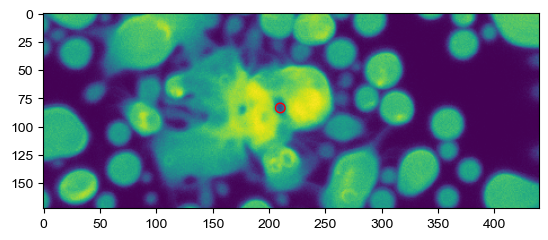

In [253]:
# identifying bleaching ROI using centers of bleach scan and recovery scan
plt.imshow(rec[0])
deltax=np.round((-rec_x+bl_x)/.1)
deltay=np.round((-rec_y+bl_y)/.1)
center_y= np.shape(rec[0])[0]/2
center_x= np.shape(rec[0])[1]/2
bl_r = np.sqrt(bl_size[0]**2+bl_size[1]**2)
bl_centx, bl_centy = center_x+deltax-10,center_y+deltay-3
circle=plt.Circle((bl_centx,bl_centy),bl_r,ec='r',facecolor='None')
ax = plt.gca()
ax.add_patch(circle)
plt.show()

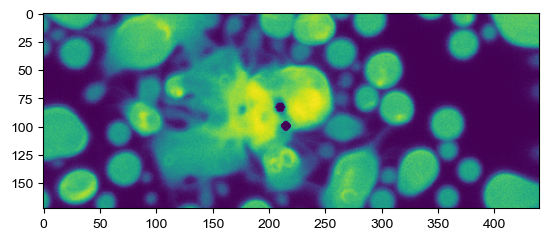

In [256]:
#creating bleaching mask and a reference mask
y,x = np.ogrid[0:np.shape(rec[0])[0], 0:np.shape(rec[0])[1]]
mask=(y-bl_centy)**2+(x-bl_centx)**2< (bl_r)**2
ref_centx = 215
ref_centy=100
y,x = np.ogrid[0:np.shape(rec[0])[0], 0:np.shape(rec[0])[1]]
mask1=(y-ref_centy)**2+(x-ref_centx)**2< (bl_r)**2
#ax.add_patch(circle)
plt.imshow(rec[0]*(1-(mask+mask1)))

bl_area=np.sum(mask)


In [257]:
#calculating time lag from end of bleach scan and end of first frame of recovery scan
imagetime=-(file1.scans[fraplis[0]].timestamps[0][0][0]-file1.scans[fraplis[0]].timestamps[1][0][0])/1e9
rec_time_end = file1.scans[fraplis[0]].timestamps[0][0][0]
timelag=(rec_time_end-bl_end_t)/1e9

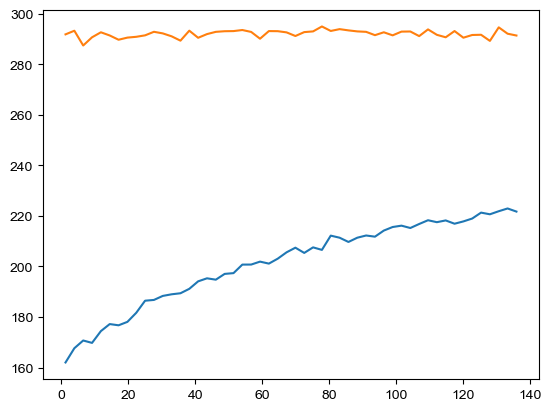

In [258]:
# getting instensity curves time corrected

bl_intensity = np.zeros(np.shape(rec)[0],)
ref_intensity = np.zeros(np.shape(rec)[0],)
time = imagetime*np.arange(np.shape(rec)[0])+timelag
for i in range(np.shape(rec)[0]):
    bl_intensity[i]=np.sum(rec[i]*mask)/np.sum(mask)
    ref_intensity[i]=np.sum(rec[i]*mask1)/np.sum(mask1)
plt.plot(time,bl_intensity,time,ref_intensity)

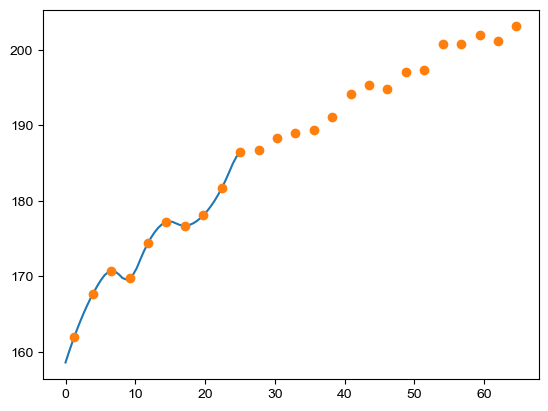

In [259]:
# estimating intensity at t=0 by interpolation of a spline

from scipy.interpolate import InterpolatedUnivariateSpline
s = InterpolatedUnivariateSpline(time[:25], bl_intensity[:25], k=2)
itrawy1=np.linspace(0,25)
plt.plot(itrawy1,s(itrawy1))
plt.plot(time[:25], bl_intensity[:25],'o')
intensity_0=s(0)




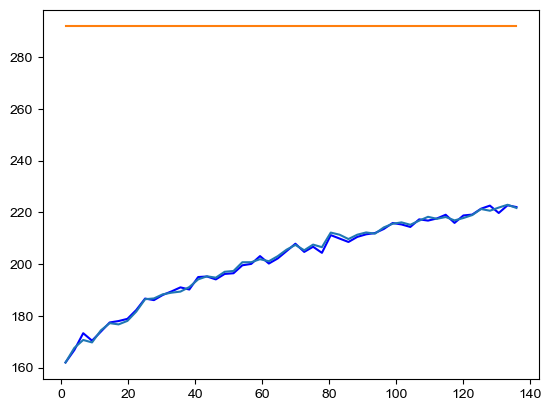

In [260]:
# correction for photofading
cf = ref_intensity[0]/ref_intensity
corrected_bl = bl_intensity*cf
plt.plot(time,corrected_bl,'b',time,bl_intensity,time,ref_intensity*cf)

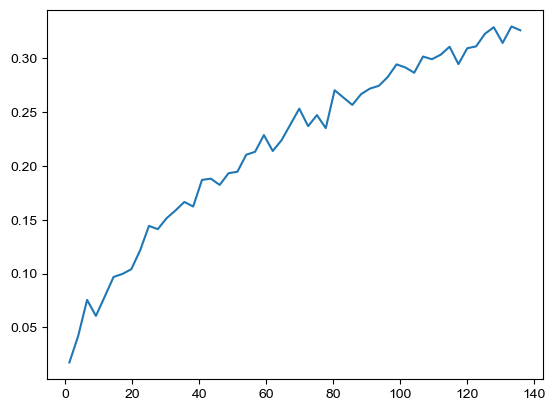

In [261]:
#normalization 
rf_int = np.zeros(np.shape(rf)[0],)
for i in range(np.shape(rf)[0]):
    rf_int[i]=np.sum(rf[0]*mask)/np.sum(mask)
prebleach = np.mean(rf_int) 
bl_norm = (corrected_bl-intensity_0)/(prebleach-intensity_0)
plt.plot(time,bl_norm)


In [262]:
# save files
np.savetxt(fname+'FRAP data.txt', np.transpose(np.array([time,bl_intensity, ref_intensity, bl_norm, cf])), delimiter='\t')

In [263]:
#compile data
import os
# input the directory of the folder containing the scans and FRAPs you want to convert to tiff and then execute all 
testdir = r"E:\Anurag_data\A1-LCD project\FRAP\A1-LCD project\D262V buffer exchange\RGYGG7-dT200\FRAP 5"
os.listdir(testdir)
os.chdir(testdir)
os.getcwd()

files = listdir()
scans = []
fraps=[]
for file in files:
    if '.txt' in file  :
        scans.append(file)
index = np.arange(len(scans))
insca = zip(list(index),scans)
list(insca)


[(0, '20240404-154657 Scan 23FRAP data.txt')]

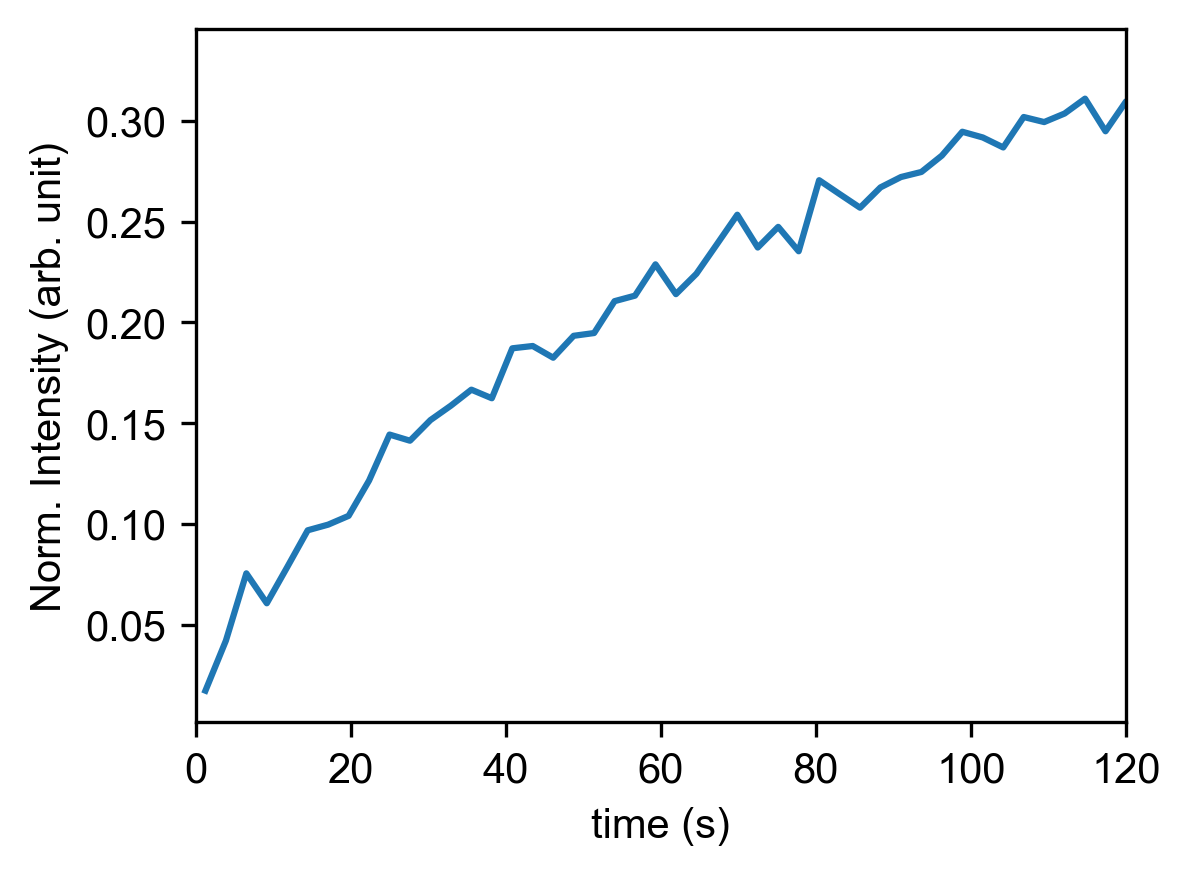

In [265]:
num = 1
intensity = []
time=[]
count=[]
plt.rcParams['font.sans-serif'] = "Arial"

plt.figure(figsize=(4,3),dpi=300)

for i in range(num):
    M=np.loadtxt(scans[i])
    time.append(M[:,0])
    intensity.append(M[:,3])
    count.append(len(M[:,0]))
    plt.plot(time[i],intensity[i])



plt.xlim(0,120)
plt.xlabel('time (s)')
plt.ylabel('Norm. Intensity (arb. unit)')
plt.savefig('recovery curves.png',bbox_inches='tight')
plt.savefig('recovery curves.svg',bbox_inches='tight')

In [266]:
length = min(count)
Int_arr=np.zeros((num,length))
t_arr = np.zeros((num,length))
for i in range(num):
    Int_arr[i,:]=intensity[i][:length]
    t_arr[i,:]=time[i][:length]
np.savetxt('recovery curves.txt', np.transpose(Int_arr),delimiter='\t')

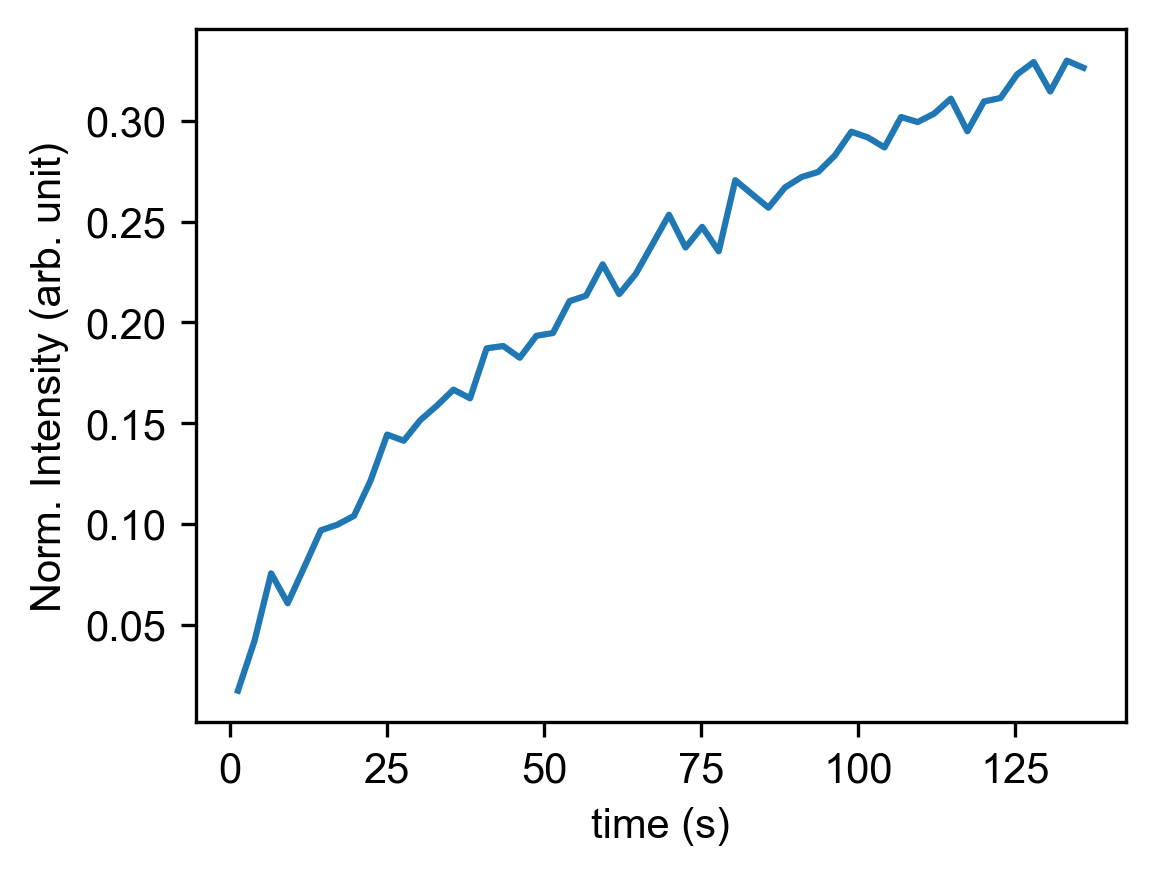

In [267]:
plt.rcParams['font.sans-serif'] = "Arial"

avg_int=np.mean(Int_arr,axis=0)
err_int=np.std(Int_arr,axis=0)
avg_t = np.mean(t_arr,axis=0)
plt.figure(figsize=(4,3),dpi=300)

plt.errorbar(avg_t,avg_int,err_int)
plt.xlabel('time (s)')
plt.ylabel('Norm. Intensity (arb. unit)')
plt.savefig('Average recovery curve.png',bbox_inches='tight')
plt.savefig('Average recovery curve.svg',bbox_inches='tight')
np.savetxt('Average curve.txt',np.transpose([avg_t,avg_int,err_int]),delimiter='\t')